In [1]:
from _devpath import prepend_local_checkout_to_path
prepend_local_checkout_to_path()

# escape — Quick Start

This notebook walks through the most common `escape` operations using synthetic data
generated by `escape.storage.example_data` — no real data files needed.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import escape
from escape.storage.example_data import make_scan, make_pump_probe_scan, make_image_scan

print(f"escape version: {escape.__version__}")

escape version: 0.0.1


## 1 — Creating a Scan Array

A ten-step delay scan with 500 events per step.
Each event has a unique pulse ID (integer) and a scalar signal value.

In [12]:
sig = make_scan(
    n_steps=10,
    n_events_per_step=500,
    scan_par_name="delay_ps",
    scan_par_values=np.linspace(-1, 4, 10),
    name="bragg_intensity",
    seed=0,
)

print(sig)
print()
print(sig.scan.par_steps)

<escape.storage.storage.Array object at 0x147d44fb8680> bragg_intensity; shape (5000,)
Step 0000:KM%MAMAdKz(2_. ,                        
Step 0001:                          .-.7ffMD$MQdAf
Step 0002:i-Vje=tZ/$]4j(_./,                      
Step 0003:                 ,- vV2zKMQWD$A*Yt|\v~- 
Step 0004:         \,/T[#mZe5N\z/|\.- .           
Step 0005:       . ,=|+v#AK)XZ4g~V~c              
Step 0006:                 - -,,]+!~ZYN#/mD~_-,-, 
Step 0007:,_G54*$MdPKW4)\ \,-.                    
Step 0008:                         -..vgYKNK8%m*5z
Step 0009:ZK$M8GbZT2ij- -                         
153              |                                
            ||||||||||| | |            | |||      
          ||||||||||||||||||||||||||||||||||||||| 
          ||||||||||||||||||||||||||||||||||||||||
0.6198                                           1.358    
Scan over 10 steps
Parameters delay_ps

   delay_ps  step_length
0 -1.000000          500
1 -0.444444          500
2  0.111111          500


## 2 — Per-Step Statistics and Plotting

All standard numpy reduction methods are available step-wise on `scan`.
`scan.plot()` shows median ± σ/√N by default.

In [13]:
means  = sig.scan.nanmean()
stds   = sig.scan.nanstd()
counts = sig.scan.count()

print(f"Step means:  {[round(float(m), 3) for m in means]}")
print(f"Event counts per step: {counts}")

Step means:  [0.697, 1.275, 0.775, 1.143, 0.945, 0.942, 1.155, 0.774, 1.285, 0.705]
Event counts per step: [500, 500, 500, 500, 500, 500, 500, 500, 500, 500]


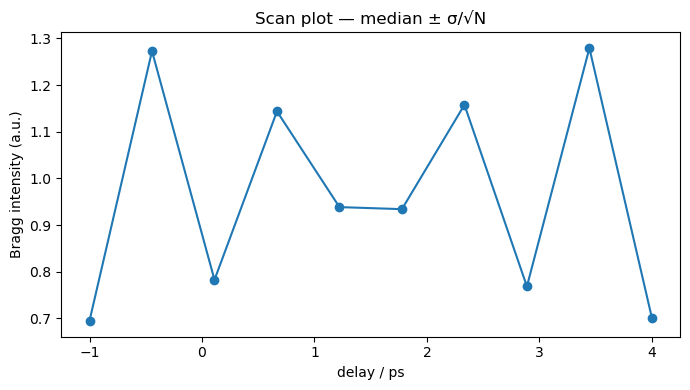

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
sig.scan.plot(axis=ax, fmt="o-")
ax.set_xlabel("delay / ps")
ax.set_ylabel("Bragg intensity (a.u.)")
ax.set_title("Scan plot — median ± σ/√N")
plt.tight_layout()
plt.show()

## 3 — Boolean Filtering

`filter()` keeps events within a value range while preserving scan structure.

Before filter: 5000 events
After  filter: 4231 events


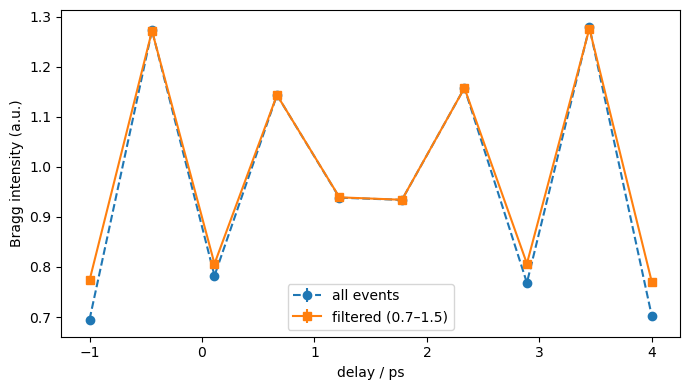

In [15]:
strong = sig.filter(0.7, 1.5)

print(f"Before filter: {len(sig.index)} events")
print(f"After  filter: {len(strong.index)} events")

fig, ax = plt.subplots(figsize=(7, 4))
sig.scan.plot(axis=ax, fmt="o--", label="all events")
strong.scan.plot(axis=ax, fmt="s-",  label="filtered (0.7–1.5)")
ax.set_xlabel("delay / ps")
ax.set_ylabel("Bragg intensity (a.u.)")
ax.legend()
plt.tight_layout()
plt.show()

## 4 — Index-Aligned Arithmetic

When two Arrays are combined with `+`, `-`, `/`, etc., `escape` automatically
finds common pulse IDs and aligns the data — no manual bookkeeping needed.

In [7]:
sig, i0, pump_on, delay = make_pump_probe_scan(n_steps=10, seed=1)

# Division aligns on common pulse IDs automatically
sig_norm = sig / i0

# Separate pump-on and pump-off shots using boolean indexing
sig_on  = sig_norm[~pump_on]   # laser ON
sig_off = sig_norm[pump_on]    # laser OFF (reference)

print(f"Total events:    {len(sig.index)}")
print(f"Pump-ON  events: {len(sig_on.index)}")
print(f"Pump-OFF events: {len(sig_off.index)}")

Total events:    6000
Pump-ON  events: 2969
Pump-OFF events: 3031


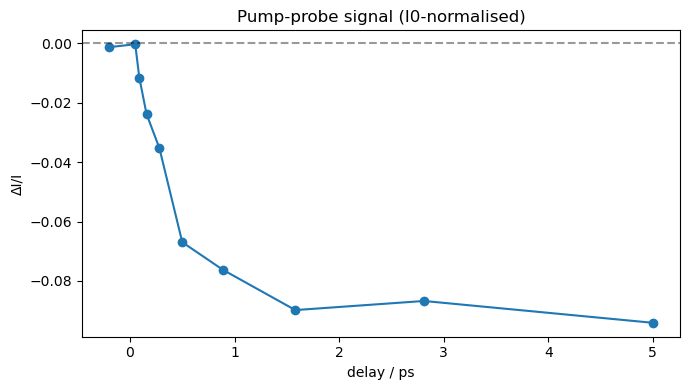

In [8]:
# Per-step means for ON and OFF
means_on  = np.asarray(sig_on.scan.nanmean())
means_off = np.asarray(sig_off.scan.nanmean())
ratio     = means_on / means_off - 1.0

delays_ps = np.asarray(sig.scan.par_steps["delay_s"]) * 1e12

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(delays_ps, ratio, "o-", lw=1.5)
ax.axhline(0, ls="--", color="k", alpha=0.4)
ax.set_xlabel("delay / ps")
ax.set_ylabel("ΔI/I")
ax.set_title("Pump-probe signal (I0-normalised)")
plt.tight_layout()
plt.show()

## 5 — Applying a Custom Function with `map_index_blocks`

For 2D data (e.g. detector images), `map_index_blocks` applies a function
chunk-by-chunk over the event axis without loading all data into memory at once.

In [9]:
imgs = make_image_scan(n_steps=3, n_events_per_step=50, seed=2)
print(f"Image array shape: {imgs.shape}  (events × rows × cols)")

# Sum a region of interest per event using standard indexing
roi = imgs[:, 25:45, 25:45]
roi_sum = roi.nansum(axis=(1, 2))
print(f"ROI sum shape: {roi_sum.shape}")

Image array shape: (150, 64, 64)  (events × rows × cols)
ROI sum shape: (150,)


In [10]:
# Apply a custom hot-pixel mask chunk-by-chunk
def hot_pixel_mask(block, threshold=200):
    out = block.copy().astype(float)
    out[out > threshold] = np.nan
    return out

imgs_clean = imgs.map_index_blocks(hot_pixel_mask, 200)

# Per-step mean image (step 0)
mean_img = imgs_clean.scan[0].nanmean(axis=0).compute()

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(mean_img, cmap="viridis")
plt.colorbar(im, ax=ax)
ax.set_title("Mean image — step 0 (hot-pixel masked)")
plt.tight_layout()
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'chunks'

## 6 — Storing Results to HDF5

`Array.store()` writes data and full scan metadata into an HDF5 group.
`Array.load_from_h5()` restores the Array with its scan structure intact.

In [ ]:
import h5py

sig, i0, pump_on, delay = make_pump_probe_scan(n_steps=10, seed=1)
sig_norm = sig / i0

with h5py.File("quickstart_results.h5", "w") as fh:
    sig_norm.store(fh, "signal_norm")
    i0.store(fh,       "i0")

# Reload and verify
with h5py.File("quickstart_results.h5", "r") as fh:
    sig_reloaded = escape.Array.load_from_h5(fh, "signal_norm")

print("Reloaded scan steps:", len(sig_reloaded.scan))
print(sig_reloaded.scan.par_steps)